# Binance Gold & Silver Perpetuals and ETF Markets

**Event study:** impact of Binance TRADFI XAUUSDT/XAGUSDT launch (2026-01-05) on GLD/SLV volatility, liquidity, and integration.

**Hypotheses:** H1 — ETF volatility increases after the launch; H2 — volume/liquidity improves. Integration (correlation ETF–Binance) is described post-event only (no pre-event Binance data).

**Data:** Uses only 3 CSV files in folder **`processed/`** (or `data/processed/`): `features_daily.csv`, `features_hourly.csv`, `features_1m.csv`. Upload this folder in Colab and run all cells. No API, no other files.


## Setup

Path to the folder with the 3 panels. We look for `data/processed/` or, if missing, `processed/` (so in Colab you can upload a folder named **processed** with the 3 CSV files).


In [1]:
import os
import sys

PROJECT_ROOT = os.getcwd()
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

# Folder with the 3 panels: try 'data/processed' then 'processed' (Colab often has just 'processed')
PROC_DIR = os.path.join(PROJECT_ROOT, 'data', 'processed')
if not os.path.exists(PROC_DIR):
    PROC_DIR = os.path.join(PROJECT_ROOT, 'processed')
os.makedirs(PROC_DIR, exist_ok=True)

PATH_DAILY = os.path.join(PROC_DIR, 'features_daily.csv')
PATH_HOURLY = os.path.join(PROC_DIR, 'features_hourly.csv')
PATH_1M = os.path.join(PROC_DIR, 'features_1m.csv')

print(f'Data folder: {PROC_DIR}')
print('daily:', os.path.exists(PATH_DAILY), '| hourly:', os.path.exists(PATH_HOURLY), '| 1m:', os.path.exists(PATH_1M))
if not os.path.exists(PATH_DAILY):
    raise FileNotFoundError('Upload features_daily.csv, features_hourly.csv, features_1m.csv to folder processed/')


Data folder: /Users/nz3000/Python/Gold_Project/data/processed
daily: True | hourly: True | 1m: True


## 0. Data

This notebook uses **only these 3 files** in the `processed` folder:
- `features_daily.csv`
- `features_hourly.csv`
- `features_1m.csv`

No API calls, no other files. If all three are present, we are ready.


In [2]:
required = [('features_daily.csv', PATH_DAILY), ('features_hourly.csv', PATH_HOURLY), ('features_1m.csv', PATH_1M)]
for name, path in required:
    print(f'{name}: {"OK" if os.path.exists(path) else "missing"}')


features_daily.csv: OK
features_hourly.csv: OK
features_1m.csv: OK


### Three panels

We have **three panels** at different frequencies. The minute panel has the largest number of observations (tens of thousands of rows).


In [3]:
import pandas as pd
proc_dir = PROC_DIR

def _panel_stats(path):
    if not os.path.exists(path): return 0, '-', 0
    try:
        with open(path, encoding='utf-8') as f: n_rows = max(0, sum(1 for _ in f) - 1)
        df = pd.read_csv(path, nrows=1)
        n_cols = len(df.columns)
        date_col = 'Date' if 'Date' in df.columns else (df.columns[0] if len(df.columns) else None)
        if date_col:
            s = pd.read_csv(path, usecols=[date_col], parse_dates=[date_col])
            if len(s): period = f"{s[date_col].min().date()} to {s[date_col].max().date()}"
            else: period = '-'
        else: period = '-'
        return n_rows, period, n_cols
    except Exception: return 0, '-', 0

panels = [
    ('Daily', 'features_daily.csv', 'Event study, regressions, pre/post'),
    ('Hourly', 'features_hourly.csv', 'Hourly returns/vol'),
    ('Minute (1m)', 'features_1m.csv', 'Intraday dynamics, very large sample'),
]

rows = []
for name, fname, desc in panels:
    path = os.path.join(proc_dir, fname)
    n_rows, period, n_cols = _panel_stats(path)
    rows.append({'Panel': name, 'File': fname, 'Rows': n_rows, 'Period': period, 'Variables': n_cols, 'Purpose': desc})

panels_table = pd.DataFrame(rows)
panels_table['Rows'] = panels_table['Rows'].astype(int)
print('Three panels (daily / hourly / 1m). Minute panel has the most observations.')
from IPython.display import display
display(panels_table)


Three panels (daily / hourly / 1m). Minute panel has the most observations.


,Panel,File,Rows,Period,Variables,Purpose
0,Daily,features_daily.csv,120,2025-09-02 to 2026-02-23,90,"Event study, regressions, pre/post"
1,Hourly,features_hourly.csv,4200,2025-09-02 to 2026-02-23,32,Hourly returns/vol
2,Minute (1m),features_1m.csv,72759,2026-01-05 to 2026-02-24,31,"Intraday dynamics, very large sample"


### All panels: data preview

Below we load and display the data from all three panels: shape, column names, and first rows.


In [4]:
import pandas as pd
from IPython.display import display

for name, fname in [('Daily', 'features_daily.csv'), ('Hourly', 'features_hourly.csv'), ('Minute (1m)', 'features_1m.csv')]:
    path = os.path.join(PROC_DIR, fname)
    if not os.path.exists(path):
        print(f'--- {name}: {fname} not found ---'); continue
    peek = pd.read_csv(path, nrows=5)
    date_col = 'Date' if 'Date' in peek.columns else (peek.columns[0] if len(peek.columns) else None)
    with open(path, encoding='utf-8') as f: n_rows = sum(1 for _ in f) - 1
    n_cols = len(peek.columns)
    df = pd.read_csv(path, parse_dates=[date_col] if date_col in peek.columns else None) if n_rows <= 5000 else pd.read_csv(path, parse_dates=[date_col] if date_col in peek.columns else None, nrows=2000)
    print(f'=== {name} ({fname}) ===')
    print(f'Shape: {n_rows} rows x {n_cols} columns')
    print(f'Columns: {list(df.columns)[:25]}{" ..." if len(df.columns) > 25 else ""}')
    display(df.head(20))
    print()


=== Daily (features_daily.csv) ===
Shape: 120 rows x 90 columns
Columns: ['Date', 'px_gld_open', 'px_gld_high', 'px_gld_low', 'px_gld_close', 'vol_gld', 'px_slv_open', 'px_slv_high', 'px_slv_low', 'px_slv_close', 'vol_slv', 'dxy', 'vix', 'tnx', 'dgs10', 'px_xau_binance_open', 'px_xau_binance_high', 'px_xau_binance_low', 'px_xau_binance_close', 'px_xau_binance_volume', 'px_xau_binance_num_trades', 'px_xag_binance_open', 'px_xag_binance_high', 'px_xag_binance_low', 'px_xag_binance_close'] ...


,Date,px_gld_open,px_gld_high,px_gld_low,px_gld_close,vol_gld,px_slv_open,px_slv_high,px_slv_low,px_slv_close,...,funding_xau_change,funding_extreme_xau,oi_xau_change,funding_xag_change,funding_extreme_xag,oi_xag_change,dxy_ret,vix_ret,tnx_ret,dgs10_ret
0,2025-09-02,320.820007,325.920013,320.239990,325.589996,21247500.0,36.630001,37.169998,36.430000,37.150002,...,NaN,0,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
1,2025-09-03,327.760010,329.450012,326.730011,328.140015,16062200.0,37.330002,37.639999,37.180000,37.340000,...,NaN,0,NaN,NaN,0,NaN,-0.002646,-0.048936,-0.015552,-0.014118
2,2025-09-04,327.029999,327.559998,325.350006,326.690002,11703100.0,37.200001,37.220001,36.630001,36.930000,...,NaN,0,NaN,NaN,0,NaN,0.002138,-0.066375,-0.008346,-0.011919
3,2025-09-05,329.529999,331.440002,328.929993,331.049988,16065200.0,37.410000,37.599998,36.970001,37.209999,...,NaN,0,NaN,NaN,0,NaN,-0.005915,-0.007874,-0.021787,-0.016929
4,2025-09-08,333.660004,335.670013,333.230011,334.820007,18617300.0,37.570000,37.830002,37.360001,37.509998,...,NaN,0,NaN,NaN,0,NaN,-0.003278,-0.004622,-0.009838,-0.012270
5,2025-09-09,337.029999,338.309998,333.850006,334.059998,21641900.0,37.430000,37.580002,37.009998,37.180000,...,NaN,0,NaN,NaN,0,NaN,0.003483,-0.004643,0.006897,0.007380
6,2025-09-10,335.730011,336.500000,326.190002,335.260010,11945700.0,37.349998,37.490002,37.240002,37.410000,...,NaN,0,NaN,NaN,0,NaN,-0.000102,0.020402,-0.010363,-0.009852
7,2025-09-11,333.369995,335.160004,332.970001,334.760010,9082600.0,37.369999,37.919998,37.330002,37.790001,...,NaN,0,NaN,NaN,0,NaN,-0.002457,-0.042588,-0.005222,-0.007453
8,2025-09-12,335.880005,336.390015,335.230011,335.420013,9619700.0,38.240002,38.450001,38.150002,38.340000,...,NaN,0,NaN,NaN,0,NaN,0.000103,0.003393,0.012389,0.012392
9,2025-09-15,336.309998,339.279999,336.230011,338.910004,10569900.0,38.299999,38.790001,38.250000,38.759998,...,NaN,0,NaN,NaN,0,NaN,-0.002566,0.061103,-0.006671,-0.002466



=== Hourly (features_hourly.csv) ===
Shape: 4200 rows x 32 columns
Columns: ['Unnamed: 0', 'px_gld_open', 'px_gld_high', 'px_gld_low', 'px_gld_close', 'vol_gld', 'px_slv_open', 'px_slv_high', 'px_slv_low', 'px_slv_close', 'vol_slv', 'dxy', 'vix', 'tnx', 'dgs10', 'px_xau_binance_open', 'px_xau_binance_high', 'px_xau_binance_low', 'px_xau_binance_close', 'px_xau_binance_volume', 'px_xau_binance_num_trades', 'px_xag_binance_open', 'px_xag_binance_high', 'px_xag_binance_low', 'px_xag_binance_close'] ...


,Unnamed: 0,px_gld_open,px_gld_high,px_gld_low,px_gld_close,vol_gld,px_slv_open,px_slv_high,px_slv_low,px_slv_close,...,px_xag_binance_high,px_xag_binance_low,px_xag_binance_close,px_xag_binance_volume,px_xag_binance_num_trades,ret_xau_binance,ret_xag_binance,ret_gld,ret_slv,post_event
0,2025-09-02 00:00:00,320.820007,325.920013,320.23999,325.589996,21247500.0,36.630001,37.169998,36.43,37.150002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2025-09-02 01:00:00,320.820007,325.920013,320.23999,325.589996,21247500.0,36.630001,37.169998,36.43,37.150002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0
2,2025-09-02 02:00:00,320.820007,325.920013,320.23999,325.589996,21247500.0,36.630001,37.169998,36.43,37.150002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0
3,2025-09-02 03:00:00,320.820007,325.920013,320.23999,325.589996,21247500.0,36.630001,37.169998,36.43,37.150002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0
4,2025-09-02 04:00:00,320.820007,325.920013,320.23999,325.589996,21247500.0,36.630001,37.169998,36.43,37.150002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0
5,2025-09-02 05:00:00,320.820007,325.920013,320.23999,325.589996,21247500.0,36.630001,37.169998,36.43,37.150002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0
6,2025-09-02 06:00:00,320.820007,325.920013,320.23999,325.589996,21247500.0,36.630001,37.169998,36.43,37.150002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0
7,2025-09-02 07:00:00,320.820007,325.920013,320.23999,325.589996,21247500.0,36.630001,37.169998,36.43,37.150002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0
8,2025-09-02 08:00:00,320.820007,325.920013,320.23999,325.589996,21247500.0,36.630001,37.169998,36.43,37.150002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0
9,2025-09-02 09:00:00,320.820007,325.920013,320.23999,325.589996,21247500.0,36.630001,37.169998,36.43,37.150002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0



=== Minute (1m) (features_1m.csv) ===
Shape: 72759 rows x 31 columns
Columns: ['open_time', 'px_xau_open', 'px_xau_high', 'px_xau_low', 'px_xau_close', 'volume', 'close_time', 'quote_volume', 'num_trades', 'taker_buy_volume', 'taker_buy_quote_volume', 'ignore', 'pair', 'interval', 'contract_type', 'px_gld_open', 'px_gld_high', 'px_gld_low', 'px_gld_close', 'vol_gld', 'px_slv_open', 'px_slv_high', 'px_slv_low', 'px_slv_close', 'vol_slv'] ...


,open_time,px_xau_open,px_xau_high,px_xau_low,px_xau_close,volume,close_time,quote_volume,num_trades,taker_buy_volume,...,px_slv_high,px_slv_low,px_slv_close,vol_slv,dxy,vix,tnx,dgs10,ret_xau_binance,post_event
0,2026-01-05 00:00:00+00:00,4361.45,4363.77,4361.45,4362.96,0.475,2026-01-05 00:00:59.999000+00:00,2072.12415,17,0.308,...,70.599998,68.519997,69.080002,103313300.0,98.269997,14.9,4.165,4.17,NaN,1
1,2026-01-05 00:01:00+00:00,4363.77,4363.78,4363.03,4363.78,0.712,2026-01-05 00:01:59.999000+00:00,3106.74882,13,0.452,...,70.599998,68.519997,69.080002,103313300.0,98.269997,14.9,4.165,4.17,0.000188,1
2,2026-01-05 00:02:00+00:00,4363.77,4364.53,4362.40,4362.40,1.063,2026-01-05 00:02:59.999000+00:00,4638.93838,12,0.849,...,70.599998,68.519997,69.080002,103313300.0,98.269997,14.9,4.165,4.17,-0.000316,1
3,2026-01-05 00:03:00+00:00,4362.41,4364.50,4362.41,4363.71,0.264,2026-01-05 00:03:59.999000+00:00,1152.02563,9,0.251,...,70.599998,68.519997,69.080002,103313300.0,98.269997,14.9,4.165,4.17,0.000300,1
4,2026-01-05 00:04:00+00:00,4363.65,4363.65,4363.13,4363.13,4.933,2026-01-05 00:04:59.999000+00:00,21523.47170,115,0.061,...,70.599998,68.519997,69.080002,103313300.0,98.269997,14.9,4.165,4.17,-0.000133,1
5,2026-01-05 00:05:00+00:00,4363.13,4365.40,4363.13,4364.80,2.203,2026-01-05 00:05:59.999000+00:00,9613.13965,63,0.913,...,70.599998,68.519997,69.080002,103313300.0,98.269997,14.9,4.165,4.17,0.000383,1
6,2026-01-05 00:06:00+00:00,4365.40,4365.98,4364.90,4364.90,1.237,2026-01-05 00:06:59.999000+00:00,5400.01446,19,1.003,...,70.599998,68.519997,69.080002,103313300.0,98.269997,14.9,4.165,4.17,0.000023,1
7,2026-01-05 00:07:00+00:00,4364.92,4365.06,4364.89,4364.89,0.366,2026-01-05 00:07:59.999000+00:00,1597.57099,5,0.285,...,70.599998,68.519997,69.080002,103313300.0,98.269997,14.9,4.165,4.17,-0.000002,1
8,2026-01-05 00:08:00+00:00,4363.99,4365.98,4363.99,4365.98,0.620,2026-01-05 00:08:59.999000+00:00,2705.94442,8,0.593,...,70.599998,68.519997,69.080002,103313300.0,98.269997,14.9,4.165,4.17,0.000250,1
9,2026-01-05 00:09:00+00:00,4365.81,4367.00,4363.91,4366.74,1.097,2026-01-05 00:09:59.999000+00:00,4789.13396,36,1.012,...,70.599998,68.519997,69.080002,103313300.0,98.269997,14.9,4.165,4.17,0.000174,1


**Full daily panel** (all rows):


In [5]:
path_daily_preview = os.path.join(PROC_DIR, 'features_daily.csv')
if os.path.exists(path_daily_preview):
    df_daily_full = pd.read_csv(path_daily_preview, index_col=0, parse_dates=True)
    print(f'Daily panel: {len(df_daily_full)} rows x {len(df_daily_full.columns)} columns')
    display(df_daily_full)
else:
    print('features_daily.csv not found.')


Daily panel: 120 rows x 89 columns


,px_gld_open,px_gld_high,px_gld_low,px_gld_close,vol_gld,px_slv_open,px_slv_high,px_slv_low,px_slv_close,vol_slv,...,funding_xau_change,funding_extreme_xau,oi_xau_change,funding_xag_change,funding_extreme_xag,oi_xag_change,dxy_ret,vix_ret,tnx_ret,dgs10_ret
Date,,,,,,,,,,,,,,,,,,,,,
2025-09-02,320.820007,325.920013,320.239990,325.589996,21247500.0,36.630001,37.169998,36.430000,37.150002,35875300.0,...,NaN,0,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
2025-09-03,327.760010,329.450012,326.730011,328.140015,16062200.0,37.330002,37.639999,37.180000,37.340000,27291200.0,...,NaN,0,NaN,NaN,0,NaN,-0.002646,-0.048936,-0.015552,-0.014118
2025-09-04,327.029999,327.559998,325.350006,326.690002,11703100.0,37.200001,37.220001,36.630001,36.930000,45258500.0,...,NaN,0,NaN,NaN,0,NaN,0.002138,-0.066375,-0.008346,-0.011919
2025-09-05,329.529999,331.440002,328.929993,331.049988,16065200.0,37.410000,37.599998,36.970001,37.209999,25435500.0,...,NaN,0,NaN,NaN,0,NaN,-0.005915,-0.007874,-0.021787,-0.016929
2025-09-08,333.660004,335.670013,333.230011,334.820007,18617300.0,37.570000,37.830002,37.360001,37.509998,25019700.0,...,NaN,0,NaN,NaN,0,NaN,-0.003278,-0.004622,-0.009838,-0.012270
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-17,450.260010,451.369995,445.529999,448.200012,10976100.0,67.269997,67.699997,65.139999,66.370003,82561700.0,...,0.000027,0,NaN,-0.000115,0,NaN,0.002886,-0.015163,-0.000987,0.002472
2026-02-18,455.809998,460.510010,455.320007,458.279999,10226300.0,69.660004,70.970001,69.070000,70.089996,63749400.0,...,0.000013,0,NaN,-0.000002,0,NaN,0.005542,-0.033579,0.006641,0.009828
2026-02-19,457.339996,461.510010,456.029999,459.559998,8411400.0,70.680000,71.669998,69.849998,71.010002,49022500.0,...,-0.000034,0,NaN,-0.000044,0,NaN,0.002351,0.030617,-0.000981,-0.002448


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
COLORS = {'gld': '#B8860B', 'slv': '#708090', 'xau': '#C9A227', 'xag': '#0D9488', 'event': '#C41E3A', 'pre': '#2E86AB', 'post': '#E94F37'}

proc_dir = PROC_DIR
path_daily = PATH_DAILY
if not os.path.exists(path_daily):
    raise FileNotFoundError('Upload features_daily.csv to data/processed/ or run section 0 to build from raw.')


---
## Working with the **hourly** panel

We load the hourly panel and use it for: hourly returns and volatility, and a short time series of hourly activity.


In [7]:
path_hourly = os.path.join(proc_dir, 'features_hourly.csv')
if os.path.exists(path_hourly):
    df_hourly = pd.read_csv(path_hourly, index_col=0, parse_dates=True).sort_index()
    print(f'Hourly panel: {len(df_hourly)} rows x {len(df_hourly.columns)} columns')
    print('Sample columns:', [c for c in df_hourly.columns if 'ret' in c or 'vol' in c][:12])
    if 'ret_gld' in df_hourly.columns and 'ret_xau_binance' in df_hourly.columns:
        print('Hourly returns (GLD, XAU) describe:')
        display(df_hourly[['ret_gld', 'ret_xau_binance']].describe())
    display(df_hourly.head(24))
else:
    print('features_hourly.csv not found. Upload it to data/processed/.')


Hourly panel: 4200 rows x 31 columns
Sample columns: ['vol_gld', 'vol_slv', 'px_xau_binance_volume', 'px_xag_binance_volume', 'ret_xau_binance', 'ret_xag_binance', 'ret_gld', 'ret_slv']
Hourly returns (GLD, XAU) describe:


,ret_gld,ret_xau_binance
count,4199.000000,1199.000000
mean,0.000093,0.000148
std,0.003354,0.004250
min,-0.108412,-0.055357
25%,0.000000,-0.001052
50%,0.000000,0.000173
75%,0.000000,0.001560
max,0.061647,0.021261


,px_gld_open,px_gld_high,px_gld_low,px_gld_close,vol_gld,px_slv_open,px_slv_high,px_slv_low,px_slv_close,vol_slv,...,px_xag_binance_high,px_xag_binance_low,px_xag_binance_close,px_xag_binance_volume,px_xag_binance_num_trades,ret_xau_binance,ret_xag_binance,ret_gld,ret_slv,post_event
2025-09-02 00:00:00,320.820007,325.920013,320.23999,325.589996,21247500.0,36.630001,37.169998,36.43,37.150002,35875300.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2025-09-02 01:00:00,320.820007,325.920013,320.23999,325.589996,21247500.0,36.630001,37.169998,36.43,37.150002,35875300.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0
2025-09-02 02:00:00,320.820007,325.920013,320.23999,325.589996,21247500.0,36.630001,37.169998,36.43,37.150002,35875300.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0
2025-09-02 03:00:00,320.820007,325.920013,320.23999,325.589996,21247500.0,36.630001,37.169998,36.43,37.150002,35875300.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0
2025-09-02 04:00:00,320.820007,325.920013,320.23999,325.589996,21247500.0,36.630001,37.169998,36.43,37.150002,35875300.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0
2025-09-02 05:00:00,320.820007,325.920013,320.23999,325.589996,21247500.0,36.630001,37.169998,36.43,37.150002,35875300.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0
2025-09-02 06:00:00,320.820007,325.920013,320.23999,325.589996,21247500.0,36.630001,37.169998,36.43,37.150002,35875300.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0
2025-09-02 07:00:00,320.820007,325.920013,320.23999,325.589996,21247500.0,36.630001,37.169998,36.43,37.150002,35875300.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0
2025-09-02 08:00:00,320.820007,325.920013,320.23999,325.589996,21247500.0,36.630001,37.169998,36.43,37.150002,35875300.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0
2025-09-02 09:00:00,320.820007,325.920013,320.23999,325.589996,21247500.0,36.630001,37.169998,36.43,37.150002,35875300.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0


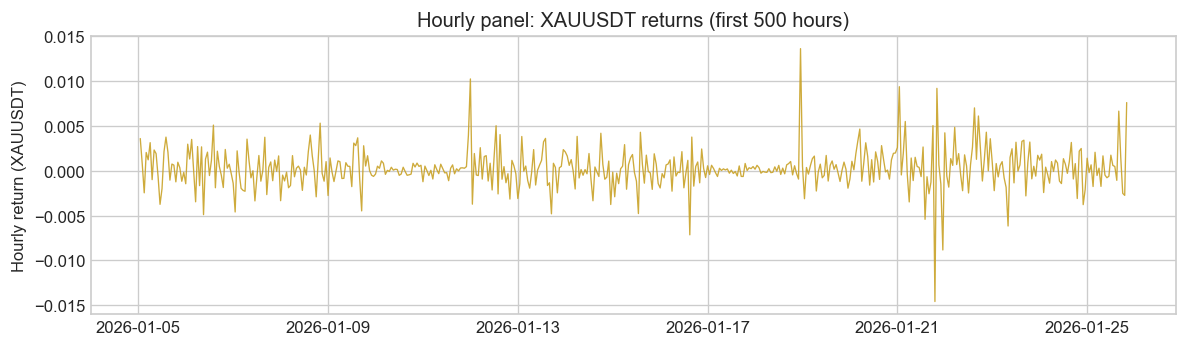

In [8]:
if os.path.exists(path_hourly) and 'ret_xau_binance' in df_hourly.columns:
    fig, ax = plt.subplots(figsize=(10, 3))
    sample = df_hourly['ret_xau_binance'].dropna().iloc[:500]
    ax.plot(sample.index, sample.values, color=COLORS['xau'], linewidth=0.8, alpha=0.9)
    ax.set_ylabel('Hourly return (XAUUSDT)')
    ax.set_title('Hourly panel: XAUUSDT returns (first 500 hours)')
    plt.tight_layout()
    plt.show()


---
## Working with the **minute** panel

We use the 1m panel for: (1) number of 1m bars per day, (2) daily realized volatility from 1m returns (XAUUSDT), (3) distribution of 1m returns.


In [9]:
path_1m = os.path.join(proc_dir, 'features_1m.csv')
if os.path.exists(path_1m):
    df_1m = pd.read_csv(path_1m, parse_dates=['open_time']).set_index('open_time').sort_index()
    df_1m.index = pd.to_datetime(df_1m.index)
    df_1m['date'] = df_1m.index.date
    bars_per_day = df_1m.groupby('date').size()
    print('1m bars per day (XAUUSDT):')
    print(bars_per_day.describe())
    print()
    if 'ret_xau_binance' in df_1m.columns:
        daily_vol = df_1m.groupby('date')['ret_xau_binance'].apply(lambda x: np.sqrt((x**2).sum()))
        print('Daily realized vol from 1m returns (annualized scale):')
        print((daily_vol * np.sqrt(365 * 24 * 60)).describe().round(4))
        print()
    summary_1m = pd.DataFrame({'n_bars': bars_per_day})
    if 'ret_xau_binance' in df_1m.columns:
        summary_1m['daily_vol_1m'] = daily_vol
    display(summary_1m.head(10))
else:
    print('features_1m.csv not found. Run the build step above.')


1m bars per day (XAUUSDT):
count      51.000000
mean     1426.647059
std        95.359074
min       759.000000
25%      1440.000000
50%      1440.000000
75%      1440.000000
max      1440.000000
dtype: float64

Daily realized vol from 1m returns (annualized scale):
count    51.0000
mean     12.7823
std       9.9335
min       1.6111
25%       7.6846
50%       9.5656
75%      14.8010
max      48.1083
Name: ret_xau_binance, dtype: float64



,n_bars,daily_vol_1m
date,,
2026-01-05,1440,0.013358
2026-01-06,1440,0.011372
2026-01-07,1440,0.013194
2026-01-08,1440,0.012175
2026-01-09,1440,0.010598
2026-01-10,1440,0.003403
2026-01-11,1440,0.004670
2026-01-12,1440,0.012913
2026-01-13,1440,0.012959


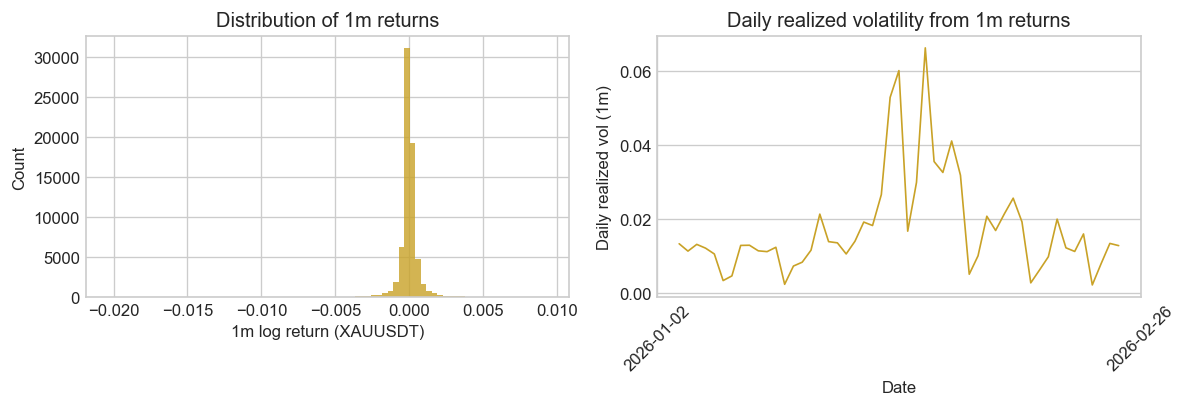

In [10]:
if os.path.exists(path_1m) and 'ret_xau_binance' in df_1m.columns:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    r = df_1m['ret_xau_binance'].dropna()
    r = r[np.isfinite(r)][r != 0]
    axes[0].hist(r, bins=80, color=COLORS['xau'], alpha=0.8, edgecolor='none')
    axes[0].set_xlabel('1m log return (XAUUSDT)')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Distribution of 1m returns')
    daily_vol = df_1m.groupby('date')['ret_xau_binance'].apply(lambda x: np.sqrt((x**2).sum()))
    x_dates = pd.to_datetime(daily_vol.index)
    axes[1].plot(x_dates, daily_vol.values, color=COLORS['xau'], linewidth=1)
    axes[1].set_xlabel('Date')
    axes[1].set_ylabel('Daily realized vol (1m)')
    axes[1].set_title('Daily realized volatility from 1m returns')
    import matplotlib.dates as mdates
    axes[1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=7))
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    axes[1].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()


---
## Working with the **daily** panel

We use the daily panel for the event study: event date, pre/post split, t-tests, OLS regressions, key results table.


### 1. Load daily panel and define event


In [11]:
df = pd.read_csv(path_daily, parse_dates=['Date']).set_index('Date').sort_index()
event_date = pd.Timestamp('2026-01-05')
core_cols = ['px_gld_close', 'px_slv_close', 'ret_gld', 'ret_slv']
df_core = df.dropna(subset=core_cols).copy()
df_core['post_event'] = (df_core.index >= event_date).astype(int)
pre = df_core['post_event'] == 0
post = df_core['post_event'] == 1

print(f'Range: {df_core.index.min().date()} to {df_core.index.max().date()}, {len(df_core)} rows x {len(df_core.columns)} columns')
df_core[['post_event']].value_counts().sort_index()


Range: 2025-09-03 to 2026-02-23, 119 rows x 89 columns


post_event
0             85
1             34
Name: count, dtype: int64

## 2. Data overview


In [12]:
df_core.head().iloc[:, :10]  # first 10 columns


,px_gld_open,px_gld_high,px_gld_low,px_gld_close,vol_gld,px_slv_open,px_slv_high,px_slv_low,px_slv_close,vol_slv
Date,,,,,,,,,,
2025-09-03,327.760010,329.450012,326.730011,328.140015,16062200.0,37.330002,37.639999,37.180000,37.340000,27291200.0
2025-09-04,327.029999,327.559998,325.350006,326.690002,11703100.0,37.200001,37.220001,36.630001,36.930000,45258500.0
2025-09-05,329.529999,331.440002,328.929993,331.049988,16065200.0,37.410000,37.599998,36.970001,37.209999,25435500.0
2025-09-08,333.660004,335.670013,333.230011,334.820007,18617300.0,37.570000,37.830002,37.360001,37.509998,25019700.0
2025-09-09,337.029999,338.309998,333.850006,334.059998,21641900.0,37.430000,37.580002,37.009998,37.180000,24001200.0


In [13]:
df_core[['ret_gld', 'ret_slv', 'vol_realized_20_ret_gld', 'vol_realized_20_ret_slv', 'vol_gld', 'vol_slv']].describe().T


,count,mean,std,min,25%,50%,75%,max
ret_gld,119.0,3.284120e-03,1.973811e-02,-1.084123e-01,-3.000703e-03,4.156538e-03,1.321148e-02,6.164735e-02
ret_slv,119.0,6.505568e-03,4.919220e-02,-3.360366e-01,-8.865872e-03,1.233176e-02,3.105176e-02,8.660244e-02
vol_realized_20_ret_gld,100.0,1.722730e-02,9.362890e-03,5.565284e-03,1.033420e-02,1.414293e-02,2.226412e-02,3.752271e-02
vol_realized_20_ret_slv,100.0,3.922929e-02,2.673755e-02,1.326043e-02,2.354656e-02,2.922815e-02,4.407721e-02,1.017807e-01
vol_gld,119.0,1.722553e+07,1.230140e+07,6.358700e+06,1.053820e+07,1.341060e+07,1.856585e+07,8.659350e+07
vol_slv,119.0,7.157554e+07,7.022934e+07,1.328920e+07,2.847650e+07,4.760340e+07,8.680090e+07,5.106877e+08


## 3. Pre- vs post-event summary (means)


In [14]:
def summarize_pre_post(series, label):
    pre = series[df_core['post_event'] == 0].dropna()
    post = series[df_core['post_event'] == 1].dropna()
    return pd.DataFrame({'metric': [label, label], 'period': ['pre', 'post'],
                         'mean': [pre.mean(), post.mean()], 'std': [pre.std(), post.std()], 'n': [len(pre), len(post)]})

rows = []
for col, label in [('vol_realized_20_ret_gld', 'GLD 20d vol'), ('vol_realized_20_ret_slv', 'SLV 20d vol'),
                   ('vol_gld', 'GLD volume'), ('vol_slv', 'SLV volume')]:
    if col in df_core.columns:
        rows.append(summarize_pre_post(df_core[col], label))
if 'corr_20_gld_xau' in df_core.columns:
    rows.append(summarize_pre_post(df_core['corr_20_gld_xau'], 'corr_20_gld_xau'))
if 'corr_20_slv_xag' in df_core.columns:
    rows.append(summarize_pre_post(df_core['corr_20_slv_xag'], 'corr_20_slv_xag'))
summary_pre_post = pd.concat(rows, ignore_index=True)
summary_pre_post


,metric,period,mean,std,n
0,GLD 20d vol,pre,1.343866e-02,6.062648e-03,66
1,GLD 20d vol,post,2.458173e-02,1.030336e-02,34
2,SLV 20d vol,pre,2.411353e-02,6.133201e-03,66
3,SLV 20d vol,post,6.857165e-02,2.695478e-02,34
4,GLD volume,pre,1.512372e+07,9.048477e+06,85
5,GLD volume,post,2.248004e+07,1.711331e+07,34
6,SLV volume,pre,4.388922e+07,2.724932e+07,85
7,SLV volume,post,1.407914e+08,9.399861e+07,34
8,corr_20_gld_xau,pre,NaN,NaN,0
9,corr_20_gld_xau,post,9.181187e-01,9.683689e-03,14


## 4. Welch t-tests (pre vs post)


In [15]:
from scipy import stats

def ttest_pre_post(series):
    pre = series[df_core['post_event'] == 0].dropna()
    post = series[df_core['post_event'] == 1].dropna()
    if len(pre) < 3 or len(post) < 3:
        return np.nan, np.nan
    t, p = stats.ttest_ind(post, pre, equal_var=False)
    return t, p

tt_rows = []
for col, label in [('vol_realized_20_ret_gld', 'GLD 20d vol'), ('vol_realized_20_ret_slv', 'SLV 20d vol'),
                   ('vol_gld', 'GLD volume'), ('vol_slv', 'SLV volume')]:
    if col in df_core.columns:
        t, p = ttest_pre_post(df_core[col])
        pre_m = df_core.loc[pre, col].mean()
        post_m = df_core.loc[post, col].mean()
        pct = (post_m - pre_m) / pre_m * 100 if pre_m and pre_m != 0 else np.nan
        tt_rows.append({'Metric': label, 'Pre mean': pre_m, 'Post mean': post_m, 'Pct': f'{pct:+.0f}%' if not np.isnan(pct) else '—',
                        't': round(t, 3) if not np.isnan(t) else '—', 't-test p': round(p, 4) if not np.isnan(p) else '—'})
tt_df = pd.DataFrame(tt_rows)
tt_df


,Metric,Pre mean,Post mean,Pct,t,t-test p
0,GLD 20d vol,1.343866e-02,2.458173e-02,+83%,5.809,0.0000
1,SLV 20d vol,2.411353e-02,6.857165e-02,+184%,9.492,0.0000
2,GLD volume,1.512372e+07,2.248004e+07,+49%,2.377,0.0222
3,SLV volume,4.388922e+07,1.407914e+08,+221%,5.913,0.0000


## 5. Cumulative returns (ETFs vs Binance)


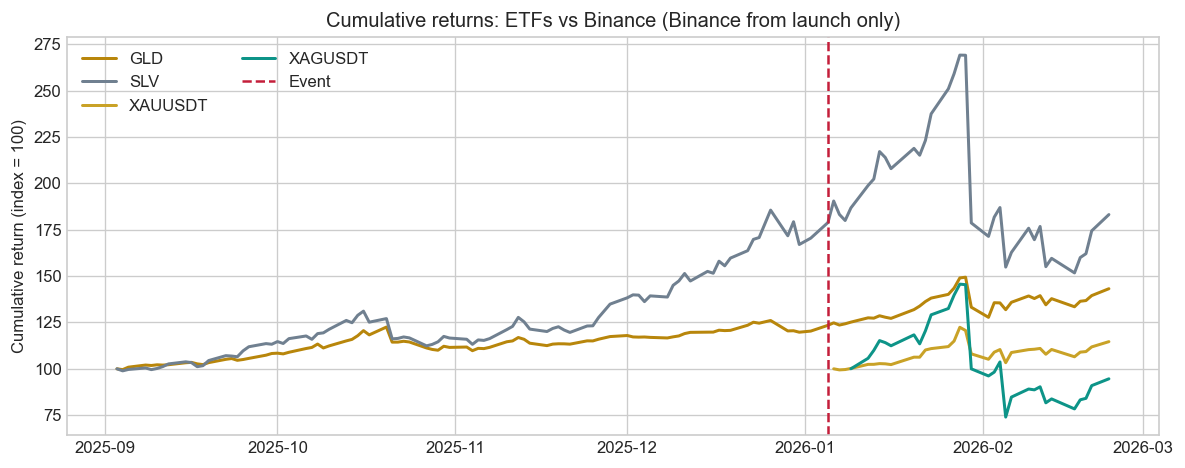

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
for col, lab, c in [('ret_gld', 'GLD', COLORS['gld']), ('ret_slv', 'SLV', COLORS['slv'])]:
    if col not in df_core.columns: continue
    r = df_core[col].fillna(0)
    cum = (1 + r).cumprod(); cum = 100 * cum / cum.iloc[0]
    ax.plot(cum.index, cum, label=lab, color=c, linewidth=1.8)
for col, lab, c in [('ret_xau_binance', 'XAUUSDT', COLORS['xau']), ('ret_xag_binance', 'XAGUSDT', COLORS['xag'])]:
    if col not in df_core.columns: continue
    post_ret = df_core.loc[df_core.index >= event_date, col].dropna()
    if post_ret.empty: continue
    cum = (1 + post_ret).cumprod(); cum = 100 * cum / cum.iloc[0]
    ax.plot(cum.index, cum, label=lab, color=c, linewidth=1.8)
ax.axvline(event_date, color=COLORS['event'], linestyle='--', linewidth=1.5, label='Event')
ax.set_ylabel('Cumulative return (index = 100)')
ax.set_title('Cumulative returns: ETFs vs Binance (Binance from launch only)')
ax.legend(loc='upper left', ncol=2)
plt.tight_layout()
plt.show()


## 6. Volatility and volume over time


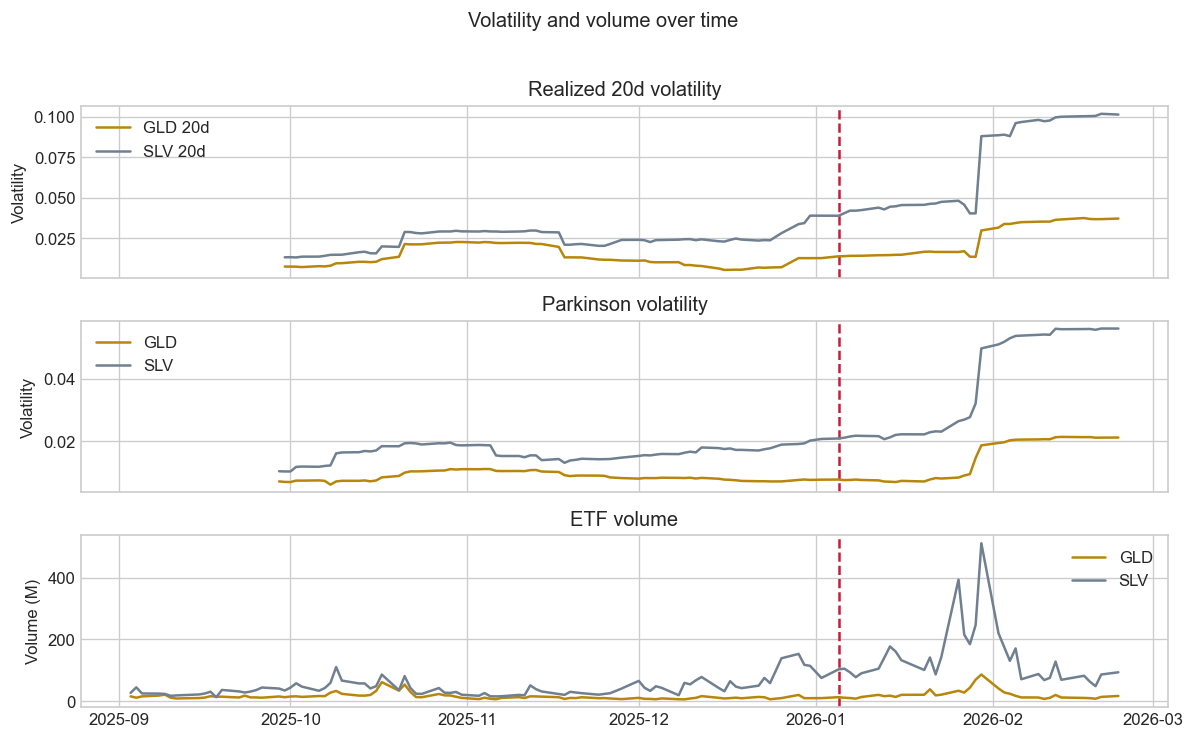

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
for ax in axes:
    ax.axvline(event_date, color=COLORS['event'], linestyle='--', linewidth=1.5)
if 'vol_realized_20_ret_gld' in df_core.columns:
    axes[0].plot(df_core.index, df_core['vol_realized_20_ret_gld'], color=COLORS['gld'], label='GLD 20d')
if 'vol_realized_20_ret_slv' in df_core.columns:
    axes[0].plot(df_core.index, df_core['vol_realized_20_ret_slv'], color=COLORS['slv'], label='SLV 20d')
axes[0].set_ylabel('Volatility'); axes[0].set_title('Realized 20d volatility'); axes[0].legend()
if 'vol_parkinson_gld' in df_core.columns:
    axes[1].plot(df_core.index, df_core['vol_parkinson_gld'], color=COLORS['gld'], label='GLD')
if 'vol_parkinson_slv' in df_core.columns:
    axes[1].plot(df_core.index, df_core['vol_parkinson_slv'], color=COLORS['slv'], label='SLV')
axes[1].set_ylabel('Volatility'); axes[1].set_title('Parkinson volatility'); axes[1].legend()
if 'vol_gld' in df_core.columns:
    axes[2].plot(df_core.index, df_core['vol_gld'] / 1e6, color=COLORS['gld'], label='GLD')
if 'vol_slv' in df_core.columns:
    axes[2].plot(df_core.index, df_core['vol_slv'] / 1e6, color=COLORS['slv'], label='SLV')
axes[2].set_ylabel('Volume (M)'); axes[2].set_title('ETF volume'); axes[2].legend()
plt.suptitle('Volatility and volume over time', y=1.02)
plt.tight_layout()
plt.show()


## 7. Pre vs post: percent change


In [18]:
pct_rows = []
for col, label in [('vol_realized_20_ret_gld', 'GLD 20d vol'), ('vol_realized_20_ret_slv', 'SLV 20d vol'),
                   ('vol_gld', 'GLD volume'), ('vol_slv', 'SLV volume')]:
    if col not in df_core.columns: continue
    pre_m, post_m = df_core.loc[pre, col].mean(), df_core.loc[post, col].mean()
    if pre_m and pre_m != 0:
        pct = (post_m - pre_m) / pre_m * 100
        pct_rows.append({'Metric': label, 'Pre mean': pre_m, 'Post mean': post_m, 'Pct change': f'{pct:+.0f}%'})
pct_df = pd.DataFrame(pct_rows)
pct_df


,Metric,Pre mean,Post mean,Pct change
0,GLD 20d vol,1.343866e-02,2.458173e-02,+83%
1,SLV 20d vol,2.411353e-02,6.857165e-02,+184%
2,GLD volume,1.512372e+07,2.248004e+07,+49%
3,SLV volume,4.388922e+07,1.407914e+08,+221%


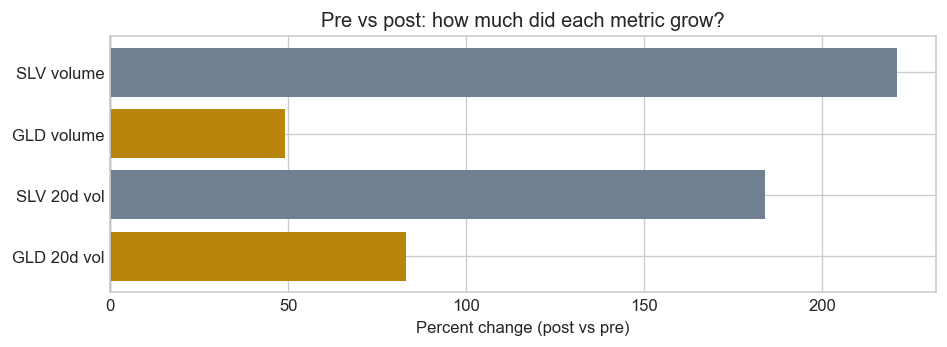

In [19]:
if len(pct_rows) >= 1:
    fig, ax = plt.subplots(figsize=(8, 3))
    labels = [r['Metric'] for r in pct_rows]
    pcts = [(float(str(r['Pct change']).replace('%', '')) if isinstance(r['Pct change'], str) else r['Pct change']) for r in pct_rows]
    colors = [COLORS['gld'] if 'GLD' in l else COLORS['slv'] for l in labels]
    y_pos = np.arange(len(labels))
    ax.barh(y_pos, pcts, color=colors)
    ax.axvline(0, color='gray', linewidth=0.8)
    ax.set_yticks(y_pos); ax.set_yticklabels(labels)
    ax.set_xlabel('Percent change (post vs pre)')
    ax.set_title('Pre vs post: how much did each metric grow?')
    plt.tight_layout()
    plt.show()


## 8. Correlation matrix (key variables)


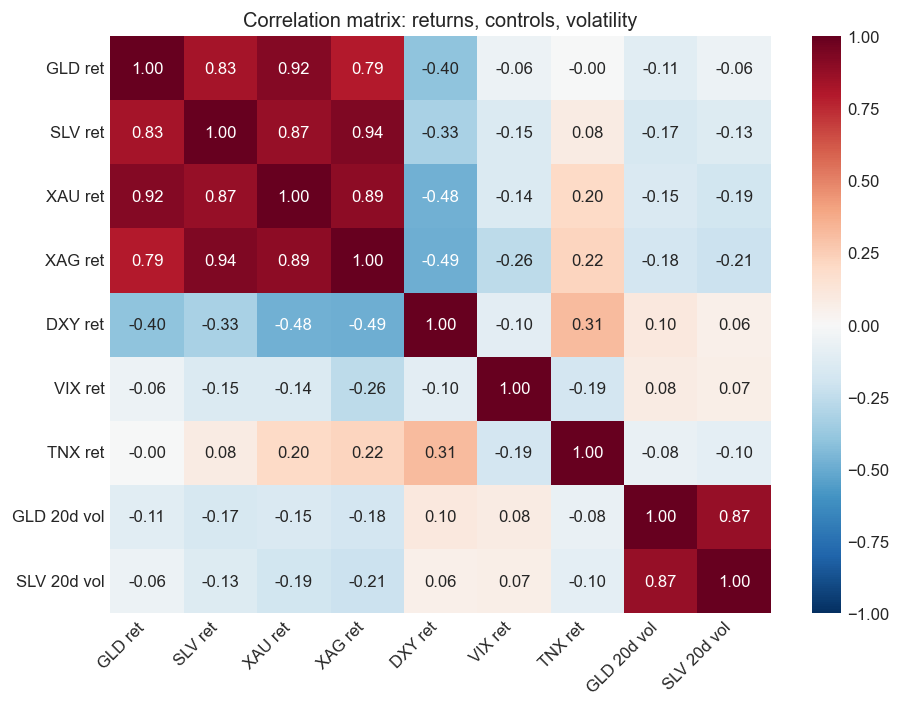

In [20]:
corr_vars = [('ret_gld', 'GLD ret'), ('ret_slv', 'SLV ret'), ('ret_xau_binance', 'XAU ret'), ('ret_xag_binance', 'XAG ret'),
             ('dxy_ret', 'DXY ret'), ('vix_ret', 'VIX ret'), ('tnx_ret', 'TNX ret'),
             ('vol_realized_20_ret_gld', 'GLD 20d vol'), ('vol_realized_20_ret_slv', 'SLV 20d vol')]
available = [(c, l) for c, l in corr_vars if c in df_core.columns]
if len(available) >= 3:
    cols = [c for c, _ in available]
    labels = [l for _, l in available]
    C = df_core[cols].corr()
    C.index = labels
    C.columns = labels
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(C, cmap='RdBu_r', center=0, vmin=-1, vmax=1, annot=True, fmt='.2f', ax=ax)
    plt.xticks(rotation=45, ha='right')
    plt.title('Correlation matrix: returns, controls, volatility')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough variables for correlation matrix')


## 9. Integration: rolling 20d correlation (post-event)


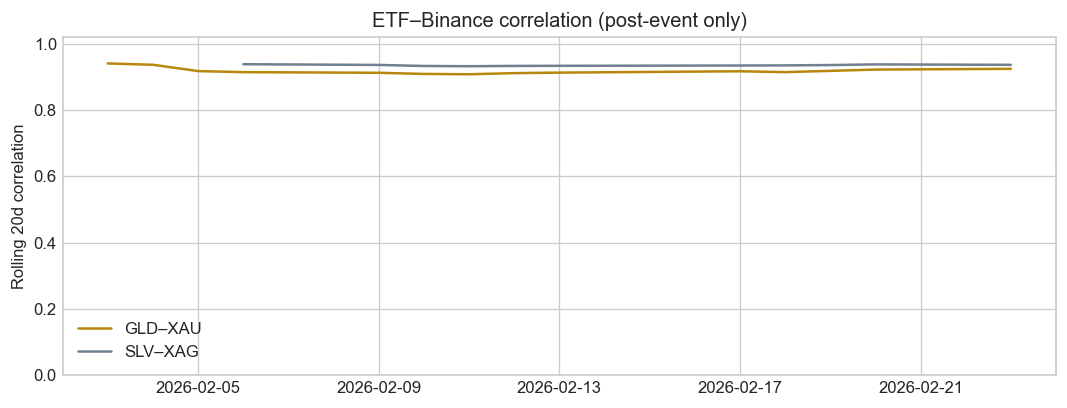

In [21]:
if 'corr_20_gld_xau' in df_core.columns or 'corr_20_slv_xag' in df_core.columns:
    fig, ax = plt.subplots(figsize=(9, 3.5))
    c_gld = df_core['corr_20_gld_xau'].dropna() if 'corr_20_gld_xau' in df_core.columns else pd.Series(dtype=float)
    c_slv = df_core['corr_20_slv_xag'].dropna() if 'corr_20_slv_xag' in df_core.columns else pd.Series(dtype=float)
    if not c_gld.empty: ax.plot(c_gld.index, c_gld.values, color=COLORS['gld'], label='GLD–XAU')
    if not c_slv.empty: ax.plot(c_slv.index, c_slv.values, color=COLORS['slv'], label='SLV–XAG')
    ax.set_ylim(0, 1.02)
    ax.set_ylabel('Rolling 20d correlation')
    ax.set_title('ETF–Binance correlation (post-event only)')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('Rolling correlation columns not in panel')


## 10. OLS regressions (post_event + controls)


In [22]:
import statsmodels.api as sm

reg_df = df_core.copy()
def winsorize(s, lower=0.05, upper=0.95):
    q = s.quantile([lower, upper])
    return s.clip(lower=q.iloc[0], upper=q.iloc[1])
for col in ['vol_realized_20_ret_gld', 'vol_realized_20_ret_slv']:
    if col in reg_df.columns:
        reg_df[f'{col}_w'] = winsorize(reg_df[col].dropna())

control_cols = ['post_event', 'dxy_ret', 'vix_ret', 'tnx_ret']
if 'dgs10_ret' in reg_df.columns:
    control_cols = ['post_event', 'dxy_ret', 'vix_ret', 'tnx_ret', 'dgs10_ret']

def run_ols(y_col, x_cols, data, use_winsor=True, hac=True):
    y_name = f'{y_col}_w' if (use_winsor and f'{y_col}_w' in data.columns) else y_col
    if y_name not in data.columns: y_name = y_col
    sub = data[[y_name] + x_cols].dropna()
    if len(sub) < 10: return None
    y = sub[y_name]
    X = sm.add_constant(sub[x_cols])
    fit = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 5}) if hac else sm.OLS(y, X).fit()
    return fit

model_gld = run_ols('vol_realized_20_ret_gld', control_cols, reg_df)
model_slv = run_ols('vol_realized_20_ret_slv', control_cols, reg_df)


In [23]:
if model_gld is not None:
    print('GLD 20d volatility:'); print(model_gld.summary().tables[1])
if model_slv is not None:
    print('SLV 20d volatility:'); print(model_slv.summary().tables[1])


GLD 20d volatility:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0133      0.002      7.877      0.000       0.010       0.017
post_event     0.0109      0.004      2.656      0.008       0.003       0.019
dxy_ret        0.4301      0.277      1.555      0.120      -0.112       0.972
vix_ret        0.0024      0.007      0.357      0.721      -0.011       0.016
tnx_ret        0.1783      0.204      0.875      0.382      -0.221       0.578
dgs10_ret     -0.2208      0.202     -1.095      0.274      -0.616       0.174
SLV 20d volatility:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0242      0.002     14.184      0.000       0.021       0.028
post_event     0.0433      0.010      4.347      0.000       0.024       0.063
dxy_ret     

## 11. Key results table


In [24]:
key_rows = []
for col, label in [('vol_realized_20_ret_gld', 'GLD 20d vol'), ('vol_realized_20_ret_slv', 'SLV 20d vol'),
                   ('vol_gld', 'GLD volume'), ('vol_slv', 'SLV volume')]:
    if col not in df_core.columns: continue
    pre_m = df_core.loc[pre, col].mean()
    post_m = df_core.loc[post, col].mean()
    t, p = ttest_pre_post(df_core[col])
    pct = (post_m - pre_m) / pre_m * 100 if pre_m and pre_m != 0 else np.nan
    coef_str, reg_p = '—', '—'
    if col.startswith('vol_realized_20') and model_gld is not None and model_slv is not None:
        mod = model_gld if 'gld' in col else model_slv
        if 'post_event' in mod.params:
            coef_str = round(mod.params['post_event'], 4)
            reg_p = round(mod.pvalues['post_event'], 3)
    key_rows.append({'Metric': label, 'Pre mean': round(pre_m, 6) if not np.isnan(pre_m) else '—',
                     'Post mean': round(post_m, 6) if not np.isnan(post_m) else '—',
                     'Pct': f'{pct:+.0f}%' if not np.isnan(pct) else '—',
                     't': round(t, 3) if not np.isnan(t) else '—', 't-test p': round(p, 4) if not np.isnan(p) else '—',
                     'post coef': coef_str, 'reg p': reg_p})
if 'corr_20_gld_xau' in df_core.columns:
    key_rows.append({'Metric': 'Corr GLD–XAU', 'Pre mean': '—', 'Post mean': round(df_core.loc[post, 'corr_20_gld_xau'].mean(), 4), 'Pct': '—', 't': '—', 't-test p': '—', 'post coef': '—', 'reg p': '—'})
if 'corr_20_slv_xag' in df_core.columns:
    key_rows.append({'Metric': 'Corr SLV–XAG', 'Pre mean': '—', 'Post mean': round(df_core.loc[post, 'corr_20_slv_xag'].mean(), 4), 'Pct': '—', 't': '—', 't-test p': '—', 'post coef': '—', 'reg p': '—'})
key_results_df = pd.DataFrame(key_rows)
key_results_df


,Metric,Pre mean,Post mean,Pct,t,t-test p,post coef,reg p
0,GLD 20d vol,0.013439,2.458200e-02,+83%,5.809,0.0,0.0109,0.008
1,SLV 20d vol,0.024114,6.857200e-02,+184%,9.492,0.0,0.0433,0.0
2,GLD volume,15123724.705882,2.248004e+07,+49%,2.377,0.0222,—,—
3,SLV volume,43889215.294118,1.407914e+08,+221%,5.913,0.0,—,—
4,Corr GLD–XAU,—,9.181000e-01,—,—,—,—,—
5,Corr SLV–XAG,—,9.347000e-01,—,—,—,—,—


## 12. Conclusions

- **H1 (volatility):** Positive and significant coefficient on `post_event` in volatility regressions (with DXY, VIX, 10Y controls) → H1 supported.
- **H2 (liquidity):** Volume and liquidity metrics improve in direction (higher volume post-event).
- **Integration:** Rolling correlation GLD–XAU and SLV–XAG is high post-event; we have no pre-event Binance data, so we describe only.
- **Limitations:** No control group (no DiD); short post window.
